# CampusDesk — Student Support Ticket Resolution (FDE Assignment)
**Lakshya Mewara · 24bcs10290 · Batch 2024-28**

**Client escalation (Dean of Student Affairs):**
> "Students keep complaining that helpdesk tickets take forever. Before we buy an AI chatbot for the helpdesk, find out what is actually happening."

This notebook is the evidence trail for the report. It walks through the same stages the pipeline runs:
**source map → retrieval → profiling & validation → workflow model → metrics → findings → what-if → reliability check**.

Data: **synthetic, realistic** — generated by `generator/generate_data.py` (seed 42). The generator simulates the real workflow (triage queue, working hours, misrouting, waiting-on-student pauses, reopens, escalations) and then injects realistic data problems.

In [1]:
import sys, json, sqlite3
from pathlib import Path
import pandas as pd
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "pipeline")); sys.path.insert(0, str(ROOT / "analysis"))
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 200); pd.set_option("display.max_colwidth", 90)
LATEST = ROOT / "output" / "latest"
RAW = ROOT / "data" / "raw" / "demo_run"
print("project root:", ROOT)

project root: /Users/lakshya0025/FDE/campusdesk-fde-assignment


## 1. Source map — where does each fact live, and which source is the source of truth?

In [2]:
source_map = pd.DataFrame([
    ("Ticket header: student, channel, intake category, priority, subject", "helpdesk.db :: tickets", "SQL", "SoT for header fields"),
    ("Student attributes (programme, year, hostel)", "helpdesk.db :: students", "SQL", "SoT"),
    ("Agents & departments", "helpdesk.db :: agents", "SQL", "SoT"),
    ("Lifecycle timestamps: created, assigned, responded, waiting, resolved, reopened, closed", "ticket_events.csv (audit-log export)", "CSV", "SoT for ALL times (ticket-table resolved_at is stale)"),
    ("Interventions: escalations, auto-reminders", "ticket_events.csv", "CSV", "SoT"),
    ("Student follow-ups & agent replies", "Portal REST API /api/v1/interactions", "API", "SoT for interactions"),
    ("Satisfaction rating", "csat_survey_export.json (nested form export)", "JSON", "directional only (34% response)"),
    ("SLA targets & rules", "sla_policy.json", "JSON", "DRAFT - not signed off"),
], columns=["information needed", "where it lives", "type", "source-of-truth decision"])
source_map

,information needed,where it lives,type,source-of-truth decision
0,"Ticket header: student, channel, intake category, priority, subject",helpdesk.db :: tickets,SQL,SoT for header fields
1,"Student attributes (programme, year, hostel)",helpdesk.db :: students,SQL,SoT
2,Agents & departments,helpdesk.db :: agents,SQL,SoT
3,"Lifecycle timestamps: created, assigned, responded, waiting, resolved, reopened, closed",ticket_events.csv (audit-log export),CSV,SoT for ALL times (ticket-table resolved_at is stale)
4,"Interventions: escalations, auto-reminders",ticket_events.csv,CSV,SoT
5,Student follow-ups & agent replies,Portal REST API /api/v1/interactions,API,SoT for interactions
6,Satisfaction rating,csat_survey_export.json (nested form export),JSON,directional only (34% response)
7,SLA targets & rules,sla_policy.json,JSON,DRAFT - not signed off


## 2. Retrieval — reproducible, raw preserved
The pipeline (`pipeline/run_pipeline.py`) pulled every source into an immutable snapshot `data/raw/<run_id>/` with a manifest (rows + sha256). The API is paginated and flaky (HTTP 500 / 429), so retrieval retries with back-off and **proves completeness** (records fetched = `total_records`, all ids unique).

In [3]:
manifest = pd.DataFrame(json.loads((RAW / "_manifest.json").read_text()))
summary = manifest.groupby("source_type").agg(files=("file", "count"), rows=("rows", "sum"))
display(summary)
manifest.head(8)

,files,rows
source_type,,
API,23,4550
CSV,1,7849
JSON,2,425
SQL,3,3069


,file,source_type,origin,rows,sha256,retrieved_at
0,sql_tickets.csv,SQL,helpdesk.db :: SELECT * FROM tickets,1254,f0632dd6228e1957,2026-09-27T18:41:48
1,sql_students.csv,SQL,"helpdesk.db :: SELECT student_id, program, year, hostel_block FROM students",1800,b4752fe418906632,2026-09-27T18:41:48
2,sql_agents.csv,SQL,"helpdesk.db :: SELECT agent_id, department, role, active FROM agents",15,acf5b132aa55ddb8,2026-09-27T18:41:48
3,csv_ticket_events.csv,CSV,ticketing tool audit-log export,7849,3b9be58f4fb33035,2026-09-27T18:41:48
4,json_csat_survey_export.json,JSON,csat_survey_export.json,424,da4c99849f3408c4,2026-09-27T18:41:48
5,json_sla_policy.json,JSON,sla_policy.json,1,6776a6817637486c,2026-09-27T18:41:48
6,api_interactions_page_001.json,API,GET /api/v1/interactions?page=1,200,d63f63d622c1921b,2026-09-27T18:41:54
7,api_interactions_page_002.json,API,GET /api/v1/interactions?page=2,200,f00c3024d812378b,2026-09-27T18:41:54


In [4]:
log = (ROOT / "logs" / "pipeline_demo_run.log").read_text().splitlines()
print("\n".join(l for l in log if "| retrieve" in l))

2026-09-27 18:41:48 | INFO    | retrieve  | SQL  tickets     1254 rows  <- SELECT * FROM tickets
2026-09-27 18:41:48 | INFO    | retrieve  | SQL  students    1800 rows  <- SELECT student_id, program, year, hostel_block FROM students
2026-09-27 18:41:48 | INFO    | retrieve  | SQL  agents        15 rows  <- SELECT agent_id, department, role, active FROM agents
2026-09-27 18:41:48 | INFO    | retrieve  | CSV  events      7849 rows  <- ticket_events.csv
2026-09-27 18:41:48 | INFO    | retrieve  | JSON csat_surv    424 rows  <- csat_survey_export.json
2026-09-27 18:41:48 | INFO    | retrieve  | JSON sla_polic      1 rows  <- sla_policy.json
2026-09-27 18:41:48 | WARNING | retrieve  | API  HTTP 429 on attempt 1/6 -> retry in 1.0s  (http://127.0.0.1:8765/api/v1/interactions?page=2&page_size=200)
2026-09-27 18:41:49 | WARNING | retrieve  | API  HTTP 500 on attempt 1/6 -> retry in 0.2s  (http://127.0.0.1:8765/api/v1/interactions?page=3&page_size=200)
2026-09-27 18:41:50 | WARNING | retrieve  |

## 3. Profiling — what does the raw data actually look like?

In [5]:
tickets_raw = pd.read_csv(RAW / "sql_tickets.csv")
events_raw = pd.read_csv(RAW / "csv_ticket_events.csv")
print("ticket rows:", len(tickets_raw), "| unique ticket_id:", tickets_raw.ticket_id.nunique())
print("\nnull % per column:"); print((100 * tickets_raw.isna().mean()).round(1)[lambda s: s > 0])
print("\nraw category values:"); print(tickets_raw.category.fillna("<NULL>").value_counts().to_string())

ticket rows: 1254 | unique ticket_id: 1230

null % per column:
priority       11.8
resolved_at    15.4
dtype: float64

raw category values:
category
IT Support              293
Hostel & Maintenance    234
Academics & Exams       199
Fees & Finance          114
Library                  90
Other                    41
IT support               34
Hostel                   33
IT                       31
academics & exams        23
hostel maintenance       22
HOSTEL                   21
it support               21
Exam Cell                19
Finance                  15
library                  14
fees & finance           13
Academics                13
Library                  12
Fees                     12


In [6]:
print("raw status values:"); print(tickets_raw.status.value_counts().to_string())
print("\ncreated_at formats:"); print(tickets_raw.created_at.str.contains("/").map({True: "DD/MM/YYYY HH:MM (email importer)", False: "ISO"}).value_counts().to_string())
print("\nevent types:"); print(events_raw.event_type.value_counts().to_string())

raw status values:
status
Closed                  923
closed                   69
CLOSED                   61
In Progress              60
Resolved                 42
Assigned                 38
Closed - No Response     25
Cancelled                22
in_progress               7
resolved                  4
closed_no_response        3

created_at formats:
created_at
ISO                                  1049
DD/MM/YYYY HH:MM (email importer)     205

event types:
event_type
status_change     2956
created           1252
assigned          1222
first_response    1190
escalated          522
reminder_sent      347
reassigned         181
agent_response     179


## 4. Business-oriented quality rules → validation gate
Every rule is a business assumption with a status: **PASS / WARN / FAIL / UNKNOWN**. Any FAIL stops the pipeline and nothing is published.

In [7]:
vr = json.loads((LATEST / "validation_report.json").read_text())
print("GATE:", vr["gate"])
pd.DataFrame(vr["checks"])[["rule_id", "rule", "status", "evidence", "action", "owner"]]

GATE: PASS WITH CAVEATS


,rule_id,rule,status,evidence,action,owner
0,R01,Every source returned data; API returned all records,PASS,empty sources: none; API completeness proven in retrieve stage,stop run if any source empty,FDE / data
1,R02,One row = one ticket (ticket_id unique),WARN,24 exact duplicate rows (1.9%); 0 conflicting ids,exact duplicates dropped (safe); conflicting ids would stop the run,FDE / data
2,R03,A student's repeat submission of the same issue is not counted twice,PASS,22 same student+subject within 15 min; 22 already marked Cancelled,Cancelled tickets excluded from KPI; the rest are NOT auto-merged (could be genuine re...,Helpdesk Manager
3,R04,created_at is a valid timestamp,WARN,200 rows in DD/MM/YYYY format (email importer); unparseable after fix: 0.0%,parsed both formats; day-first confirmed against the audit log (R06),FDE / data
4,R05,Every audit-log event belongs to a known ticket,WARN,40 orphan events (0.5%); 77 duplicate events dropped,"orphans quarantined, not joined",IT admin (ticketing tool)
5,R06,Every ticket has a 'created' event and both systems agree on created_at,PASS,tickets with audit-log lifecycle: 100.0%; created_at agreement within 1 min: 99.3% (DD...,source of truth for lifecycle times = audit log; stop run if lifecycle coverage < 98%,FDE / data
6,R07,'created' is the first event of every ticket (nothing happens before creation),WARN,8 tickets (0.7%) have events before 'created' (6 even resolved before creation); chann...,excluded from KPI (not guessed); walk-in desk clock to be fixed,IT admin (walk-in desk PC)
7,R08,Each ticket maps to one canonical category,WARN,"20 raw values -> 5 canonical + Unknown; representation fixes=1088, semantic mappings=1...",semantic mappings applied provisionally; analysis uses RESOLVING department from audit...,Helpdesk Manager
8,R09,Every status maps to a known lifecycle state,PASS,11 raw values -> 6 canonical; unmapped=0,casing/underscore variants normalised,FDE / data
9,R10,Every ticket has a priority (it sets the SLA target),WARN,"145 tickets (11.8%) missing priority, all email channel",defaulted to 'Medium' per draft policy; KPI sensitivity reported,Helpdesk Manager


In [8]:
print("Safe fixes applied:"); [print(" -", f) for f in vr["fixes"]]
print("\nAssumptions (need owner confirmation):"); [print(" -", a) for a in vr["assumptions"]];

Safe fixes applied:
 - Dropped 24 exact duplicate ticket rows (email importer double-sync).
 - Parsed 200 DD/MM/YYYY HH:MM timestamps (email importer) alongside ISO format.
 - Dropped 77 duplicate audit-log events (same event_id).
 - Normalised category casing/whitespace (e.g. 'it support', 'HOSTEL ' -> canonical).
 - Normalised status variants (e.g. 'closed', 'in_progress', 'closed_no_response').
 - CSAT: normalised ticket refs, cast string ratings to int, dropped out-of-range, kept latest per ticket.

Assumptions (need owner confirmation):
 - Semantic category mappings pending owner confirmation: Academics, Exam Cell, Fees, Finance, HOSTEL, Hostel, IT.
 - Missing priority (email tickets) = Medium, per draft SLA policy default.


## 5. Workflow model — entities, events, interactions, interventions, outcomes
Raw systems are organised by source. The model re-organises them around the **ticket's journey**:

`dim_student 1─* fact_ticket 1─* fact_ticket_event` · `fact_ticket 1─* fact_interaction` · `fact_ticket 1─* fact_intervention` · `fact_ticket 1─0..1 fact_csat` → **`ticket_journey`** (1 row per ticket)

In [9]:
con = sqlite3.connect(LATEST / "warehouse.db")
pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", con).assign(
    rows=lambda d: [con.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0] for t in d.name])

,name,rows
0,dim_student,1800
1,dim_agent,15
2,fact_ticket,1230
3,fact_ticket_event,7732
4,fact_interaction,4550
5,fact_intervention,853
6,fact_csat,394
7,ticket_journey,1230


### Reconstructing three real journeys (on-time, breached after misrouting, escalated)

In [10]:
j = pd.read_csv(LATEST / "ticket_journey.csv", parse_dates=["created_at"])
k = j[j.in_kpi_population]
picks = {
  "on time": k[(k.sla_met == 1) & (k.reassign_count == 0) & (~k.escalated)].ticket_id.iloc[0],
  "breached after misrouting": k[(k.sla_met == 0) & (k.reassign_count >= 1)].ticket_id.iloc[0],
  "escalated after breach": k[k.escalated_after_sla_breach].ticket_id.iloc[0],
}
ev = pd.read_sql("SELECT * FROM fact_ticket_event", con, parse_dates=["event_time"])
it = pd.read_sql("SELECT * FROM fact_interaction", con)
for label, tid in picks.items():
    row = j.set_index("ticket_id").loc[tid]
    print(f"\n=== {label}: {tid} | priority {row.priority} (SLA {row.sla_target_hours:.0f}h) | net {row.net_resolution_hours:.1f}h | sla_met={bool(row.sla_met)}")
    tl = ev[ev.ticket_id == tid].sort_values("event_time")[["event_time", "event_type", "to_status", "department", "actor_id", "note"]]
    print(tl.to_string(index=False))


=== on time: TKT-100001 | priority Medium (SLA 72h) | net 53.6h | sla_met=True
         event_time     event_type   to_status           department actor_id                                note
2026-07-27 13:44:08        created         New                  NaN STU25730                       channel=email
2026-07-27 14:08:16       assigned    Assigned Hostel & Maintenance   AGT013                  assigned_to=AGT006
2026-07-27 18:58:20 first_response In Progress Hostel & Maintenance   AGT006                                 NaN
2026-07-29 19:21:15  status_change    Resolved Hostel & Maintenance   AGT006                 resolution provided
2026-08-01 19:21:15  status_change      Closed Hostel & Maintenance   SYSTEM auto-closed 3 days after resolution

=== breached after misrouting: TKT-100002 | priority Low (SLA 120h) | net 211.8h | sla_met=False
         event_time     event_type   to_status        department actor_id                                    note
2026-07-27 13:09:59        cre

### The one-row-per-ticket journey table (stage durations add up exactly to total time)

In [11]:
cols = ["ticket_id", "priority", "resolving_department", "channel", "triage_hours", "first_response_wait_hours", "rerouting_hours",
        "work_hours", "pause_hours", "reopen_cycle_hours", "net_resolution_hours", "sla_target_hours", "sla_met",
        "reassign_count", "followup_count", "escalated", "csat_rating"]
k[cols].head(8).round(1)

,ticket_id,priority,resolving_department,channel,triage_hours,first_response_wait_hours,rerouting_hours,work_hours,pause_hours,reopen_cycle_hours,net_resolution_hours,sla_target_hours,sla_met,reassign_count,followup_count,escalated,csat_rating
0,TKT-100001,Medium,Hostel & Maintenance,email,0.4,4.8,0.0,48.4,0.0,0.0,53.6,72,1.0,0,2,False,NaN
1,TKT-100002,Low,Academics & Exams,portal,0.2,123.5,64.8,23.3,0.0,0.0,211.8,120,0.0,1,5,True,NaN
2,TKT-100003,Medium,Hostel & Maintenance,portal,0.2,27.0,0.0,45.9,0.0,0.0,73.2,72,0.0,0,0,True,NaN
3,TKT-100004,Low,Fees & Finance,portal,1.1,23.5,0.0,41.6,29.1,0.0,66.2,120,1.0,0,1,True,NaN
4,TKT-100005,Medium,IT Support,portal,0.2,10.6,26.3,4.7,41.0,0.0,41.8,72,1.0,1,2,True,NaN
5,TKT-100006,Medium,Academics & Exams,portal,2.8,3.3,0.0,45.9,0.0,0.0,52.1,72,1.0,0,1,True,5.0
6,TKT-100007,Low,Fees & Finance,portal,0.1,74.5,0.0,98.3,0.0,0.0,172.8,120,0.0,0,7,True,NaN
7,TKT-100008,Medium,IT Support,portal,0.2,1.0,0.0,15.0,0.0,0.0,16.3,72,1.0,0,1,False,4.0


## 6. Metrics — computed with SQL joins/aggregations over the model
**Project KPI:** SLA compliance rate = resolved tickets meeting their priority SLA (net of waiting-on-student time) ÷ resolved tickets.

In [12]:
from metrics import connect, KPI_SQL, SUPPORTING_SQL, SEGMENT_SQL
con = connect(LATEST / "warehouse.db")
print(KPI_SQL); display(pd.read_sql(KPI_SQL, con))
pd.DataFrame([(k2, con.execute(v).fetchone()[0]) for k2, v in SUPPORTING_SQL.items()], columns=["metric", "value"])


SELECT COUNT(*)                                   AS resolved_tickets,
       SUM(sla_met)                               AS met_sla,
       ROUND(100.0 * AVG(sla_met), 1)             AS sla_compliance_pct
FROM ticket_journey WHERE in_kpi_population = 1



,resolved_tickets,met_sla,sla_compliance_pct
0,1069,675.0,63.1


,metric,value
0,M1_median_first_response_h,17.90
1,M2_median_manual_triage_wait_h,13.20
2,M3_reassignment_rate_pct,12.40
3,M4_reopen_rate_pct,9.40
4,M5_avg_csat,3.69
5,M5_csat_response_rate_pct,36.50


In [13]:
print(SEGMENT_SQL["by_reassignment"])
pd.read_sql(SEGMENT_SQL["by_reassignment"], con)


        SELECT CASE WHEN reassign_count = 0 THEN '0 (routed right first time)'
                    WHEN reassign_count = 1 THEN '1 reassignment' ELSE '2+ reassignments' END AS segment,
               COUNT(*) AS tickets, ROUND(100.0 * AVG(sla_met), 1) AS sla_pct,
               ROUND(MEDIAN(net_resolution_hours), 1) AS median_net_h,
               ROUND(AVG(followup_count), 2) AS avg_followups,
               ROUND(100.0 * AVG(reopened), 1) AS reopen_pct
        FROM ticket_journey WHERE in_kpi_population = 1 GROUP BY 1 ORDER BY 1


,segment,tickets,sla_pct,median_net_h,avg_followups,reopen_pct
0,0 (routed right first time),936,65.6,48.6,1.89,8.9
1,1 reassignment,111,51.4,74.8,2.77,11.7
2,2+ reassignments,22,18.2,139.4,5.73,18.2


In [14]:
for name in ["by_priority", "by_department", "by_channel", "by_triage_path", "by_weekend", "interventions", "reminders", "followups_vs_outcome", "population"]:
    print("\n##", name); print(pd.read_sql(SEGMENT_SQL[name], con).to_string(index=False))


## by_priority
segment  target_h  tickets  sla_pct  median_net_h  median_first_resp_h
   High        24      139     20.9          57.9                 19.3
 Medium        72      682     63.6          52.7                 18.2
    Low       120      248     85.5          51.3                 16.3

## by_department
             segment  tickets  sla_pct  median_net_h  reassigned_pct
      Fees & Finance      138     27.5         115.9            14.5
   Academics & Exams      194     45.4          84.4            10.8
Hostel & Maintenance      287     55.1          70.0            13.6
             Library       79     84.8          34.9            13.9
          IT Support      371     87.3          25.4            11.3

## by_channel
segment  tickets  sla_pct  manual_triage_pct  median_triage_h
 portal      672     62.1               10.4              0.1
  email      355     63.1               89.3             11.4
walk_in       42     81.0                4.8              0.2

## b

## 7. Findings (charts from the pipeline run)

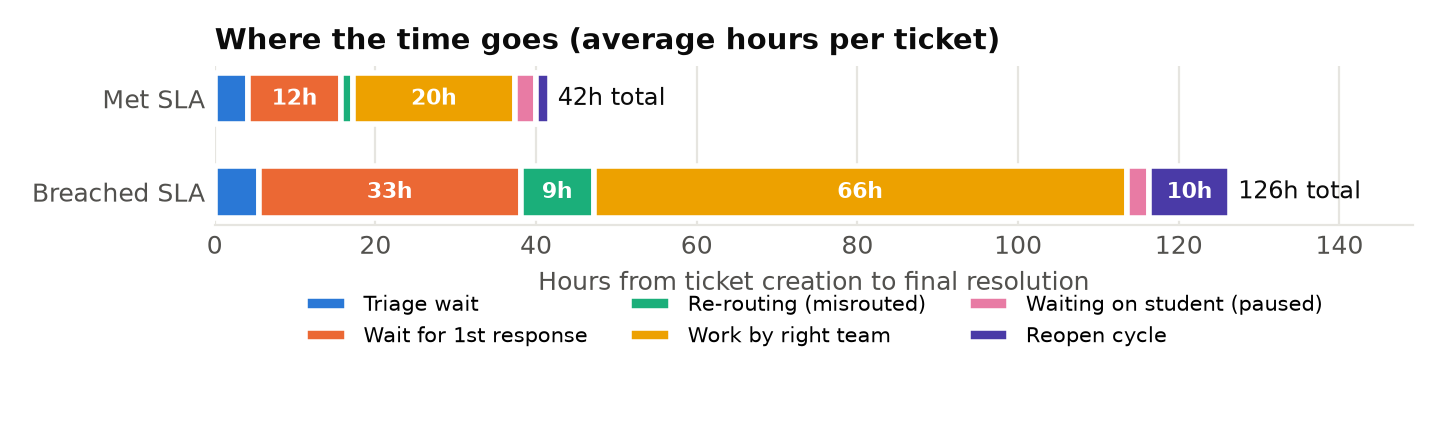

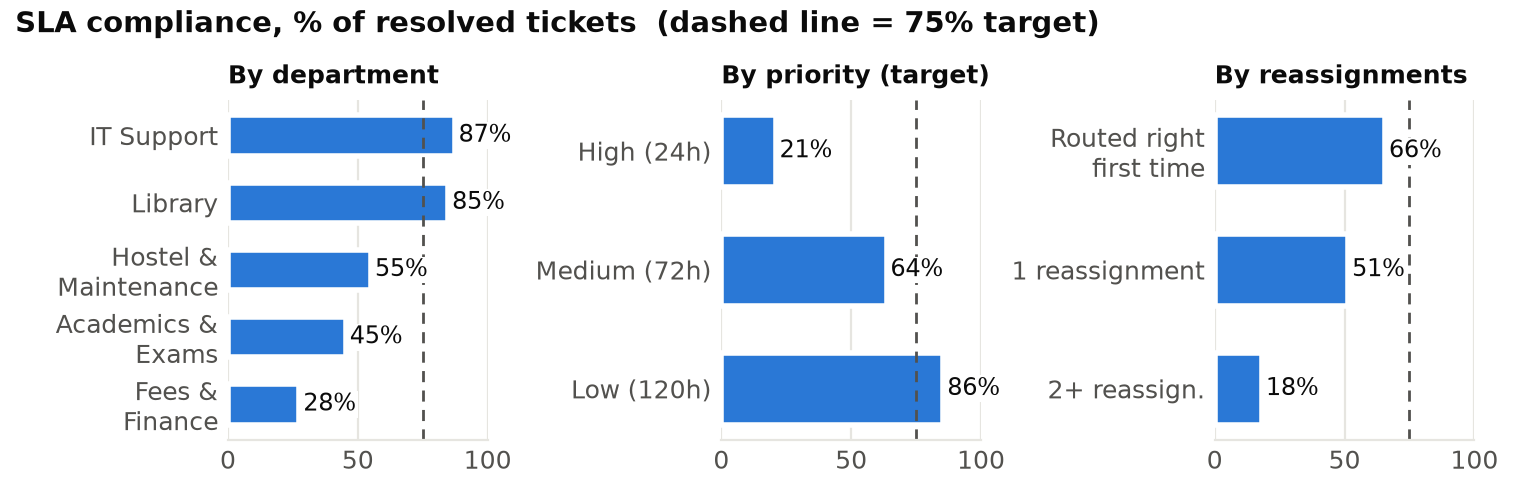

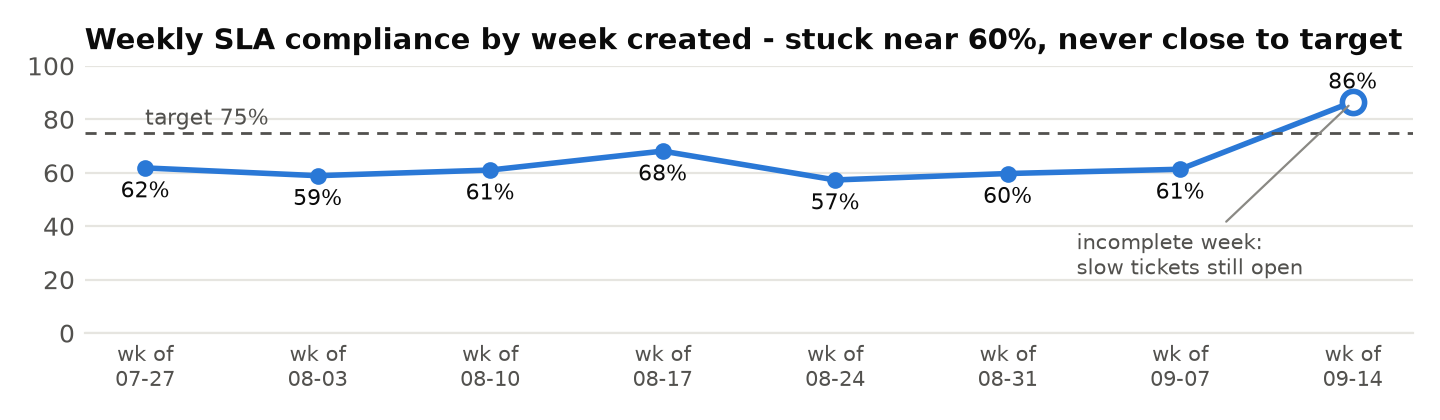

In [15]:
from IPython.display import Image, display
for f in ["stage_breakdown.png", "sla_segments.png", "weekly_trend.png"]:
    display(Image(filename=str(LATEST / "charts" / f), width=820))

**Hypotheses tested** (hypothesis tree from the problem brief):

| Hypothesis | Verdict | Evidence |
|---|---|---|
| H1 Misrouting / manual triage adds delay | **Supported** | 0 reassignments 63% SLA → 1: 45% → 2+: 31%; manual triage queue median 12.9h vs 0.1h auto |
| H2 Priority is captured but not used | **Supported** | High = 21% SLA; median first response ~18h for High, Medium *and* Low |
| H3 Some departments are capacity/hours-constrained | **Supported** | Finance 34%, Academics 44% (Mon–Fri 9–5 only) vs IT 82% |
| H4 Escalation comes too late to help | **Supported (association)** | Median escalation at 64–89h; 159 tickets escalated *after* SLA already breached |
| H5 Weekend tickets are the main problem | **Weak / mostly rejected** | weekend 58.5% vs weekday 60.9% |

*Association ≠ causation* — e.g. escalated tickets breach more because only slow tickets get escalated.

In [16]:
print(pd.read_sql(SEGMENT_SQL["stage_breakdown_breached"], con).to_string(index=False))

     segment  triage  first_response_wait  rerouting  work  waiting_on_student  reopen_cycle
breached SLA     5.5                 32.6        9.1  66.3                 2.8          10.1
     met SLA     4.2                 11.5        1.5  20.2                 2.6           1.7


## 8. Is the KPI definition robust? (why the owner must sign off)

In [17]:
pd.read_csv(LATEST / "segments" / "sensitivity.csv")

,definition,sla_compliance_pct
0,"A. Chosen: final resolution, net of waiting-on-student, missing priority = Medium",63.1
1,B. Gross calendar hours (no pause for waiting-on-student),61.7
2,C. First resolution instead of final (ignores reopens),65.9
3,D. Missing priority treated as High (24h),57.5
4,E. Also count still-open tickets already past deadline as breaches,60.9


## 9. What-if sizing of the recommended fixes (estimates, assumptions stated)

In [18]:
from what_if import scenarios
scenarios(j)[["scenario", "est_sla_compliance_pct", "uplift_pp", "est_high_priority_sla_pct", "key_assumption"]]

,scenario,est_sla_compliance_pct,uplift_pp,est_high_priority_sla_pct,key_assumption
0,Baseline (today),63.1,0.0,20.9,measured
1,S1 Fix intake routing,68.6,5.5,26.6,removed time is not replaced by other waiting
2,S2 Priority-first queue,64.6,1.5,32.4,High first-response wait falls 80% (to ~3h)
3,S3 Escalate at 50% of SLA,72.9,9.8,29.5,"escalation cuts remaining time by 40% - NOT measured, must be piloted"
4,S1 + S2,70.2,7.1,38.8,as above
5,S1 + S2 + S3,78.8,15.7,48.9,as above


## 10. Reliability — does the pipeline recover the truth? Does it fail safely?
The generator's hidden ground truth is used **only here** (never by the pipeline).

In [19]:
pd.read_csv(LATEST / "reconciliation.csv")

,method,tickets,sla_compliance,error_vs_truth_pp
0,Ground truth (simulated),1077,63.5,0.0
1,Pipeline (cleaned + modelled),1069,63.1,-0.4
2,Naive query on ticket table,714,64.6,1.1


In [20]:
for run in ["demo_fail_api_outage", "demo_fail_truncated_events"]:
    lines = (ROOT / "logs" / f"pipeline_{run}.log").read_text().splitlines()
    print(f"\n##### {run}"); print("\n".join(l for l in lines if ("ERROR" in l or "FAIL" in l or "exit code" in l or "SIMULATION" in l)))
    print("run_status:", json.loads((ROOT / "output" / "runs" / run / "run_status.json").read_text())["exit_code"])
print("\noutput/latest still holds:", json.loads((LATEST / "metrics.json").read_text())["run_id"])


##### demo_fail_api_outage
2026-09-27 18:42:01 | ERROR   | retrieve  | API  HTTP 503 on attempt 6/6 -> giving up  (http://127.0.0.1:8765/api/v1/interactions?page=1&page_size=200)
2026-09-27 18:42:01 | ERROR   | run       | STAGE FAILURE: API retries exhausted for http://127.0.0.1:8765/api/v1/interactions?page=1&page_size=200 -> run aborted, metrics NOT published, output/latest left unchanged
2026-09-27 18:42:01 | INFO    | run       | === run finished, exit code 2 ===
run_status: 2

##### demo_fail_truncated_events
2026-09-27 18:42:02 | WARNING | retrieve  | SIMULATION: ticket_events.csv export truncated to 50%
2026-09-27 18:42:08 | ERROR   | validate  | R06 FAIL    Every ticket has a 'created' event and both systems agree on created_at :: tickets with audit-log lifecycle: 50.0%; created_at agreement within 1 min: 99.5% (DD/MM rows agree only when parsed day-first)
2026-09-27 18:42:08 | INFO    | validate  | VALIDATION GATE: FAIL
2026-09-27 18:42:08 | ERROR   | validate  | gate FAILED

## 11. What remains unknown
- **Why** tickets are misrouted — no reason code is captured on reassignment.
- **Actual agent effort** — no time tracking; "work" time includes queueing inside the department.
- **Escalation effect** — only slow tickets get escalated, so its causal effect is unmeasured (needs a pilot).
- **CSAT bias** — 35% response rate, and unhappy students respond more.
- **SLA definition** — calendar vs business hours and the pause rule are not signed off (sensitivity 56.8%–64.2%).
- **Walk-in desk clock** — 8 tickets have events before creation; the desk PC clock needs fixing.